In [5]:
import torch
from train import train
from lofi_model import LofiModel
from dataset import MidiDataset
import pretty_midi
import numpy as np
from config import *
print(torch.__version__)
print(torch.version.cuda)

2.7.1+cu118
11.8


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
model = LofiModel()
model.load_state_dict(torch.load("./saved_models/progress/lofi-model_epoch130.pth"))
model.to(device)
model.eval()

LofiModel(
  (encoder): Encoder(
    (lstm): LSTM(61, 256, num_layers=2, batch_first=True, bidirectional=True)
    (fc_mean): Linear(in_features=512, out_features=128, bias=True)
    (fc_logvar): Linear(in_features=512, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (lstm): LSTM(61, 256, num_layers=2, batch_first=True)
    (fc): Linear(in_features=256, out_features=61, bias=True)
  )
  (fc_latent_to_hidden): Linear(in_features=128, out_features=512, bias=True)
  (fc_latent_to_cell): Linear(in_features=128, out_features=512, bias=True)
)

## Reconstruction

In [7]:
dataset_dir = r"C:\Users\Hyperbook\Desktop\STUDIA\SEM III\PROJEKT ZESPOLOWY\dataset\maestro-piano-dataset"
dataset = MidiDataset(dataset_dir, verbose=True)

Processing file: MIDI-UNPROCESSED_04-05_R1_2014_MID--AUDIO_04_R1_2014_wav--1
Original sequence:


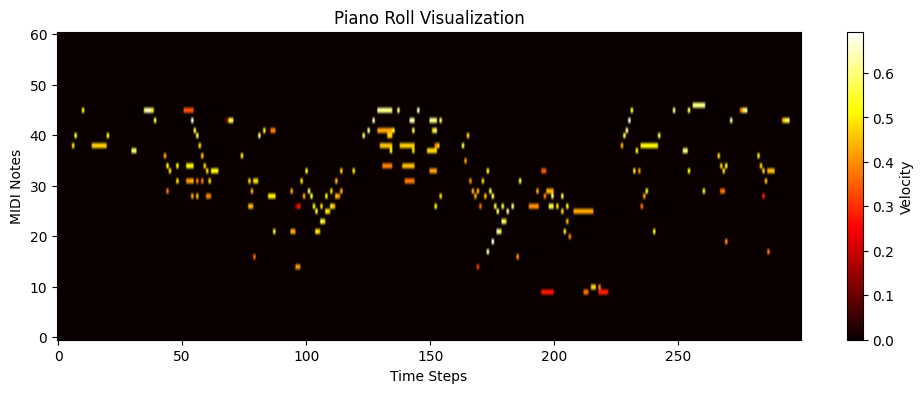

Reconstruction:


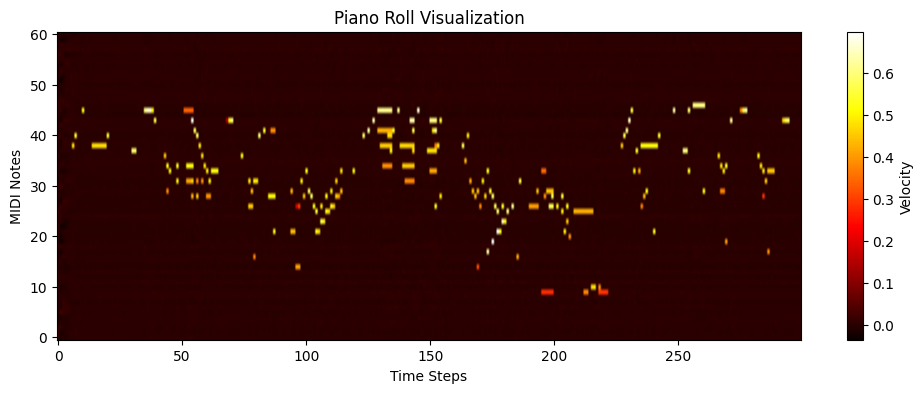

________________________________________________________________________________________________________________________

Processing file: MIDI-UNPROCESSED_04-05_R1_2014_MID--AUDIO_04_R1_2014_wav--2
Original sequence:


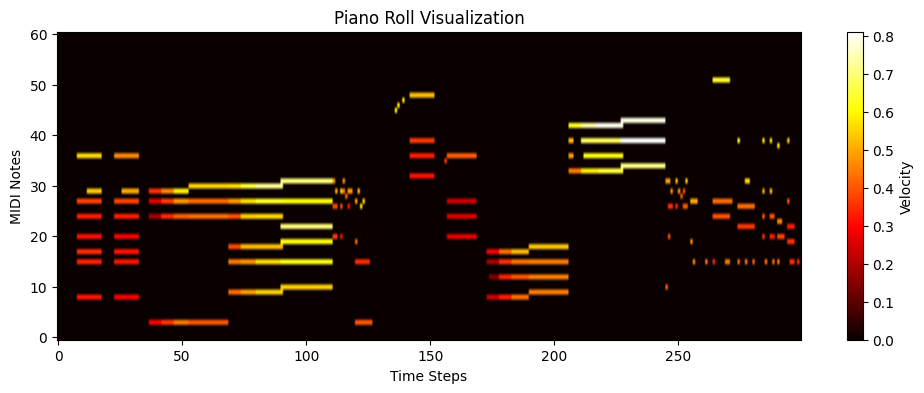

Reconstruction:


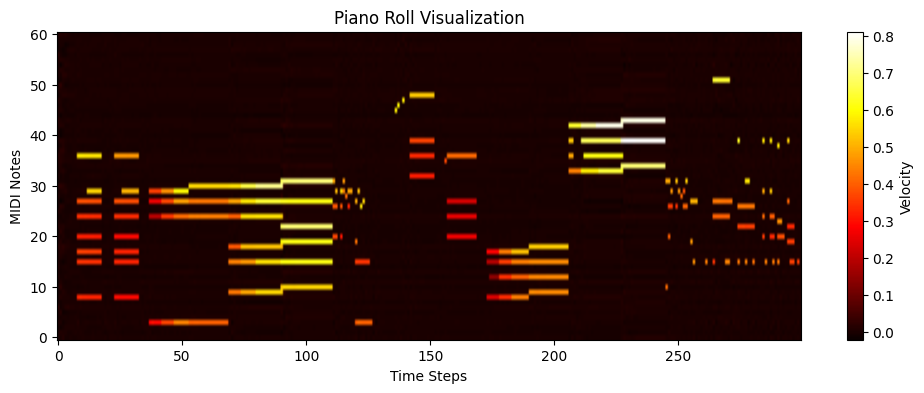

________________________________________________________________________________________________________________________

Processing file: MIDI-UNPROCESSED_04-05_R1_2014_MID--AUDIO_04_R1_2014_wav--3
Original sequence:


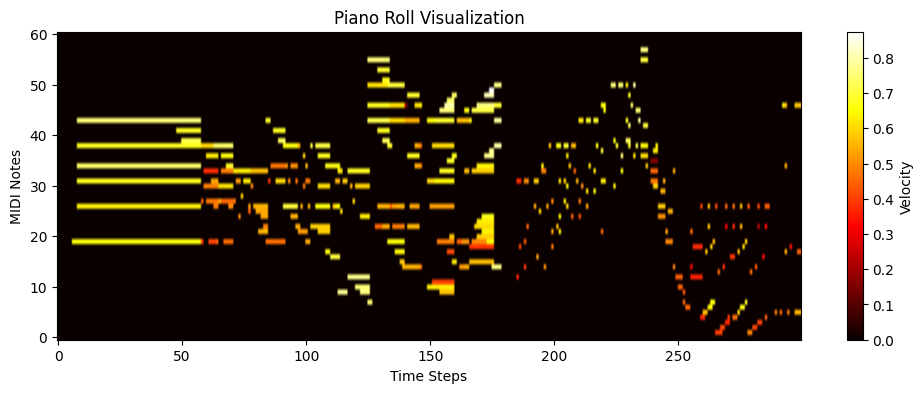

Reconstruction:


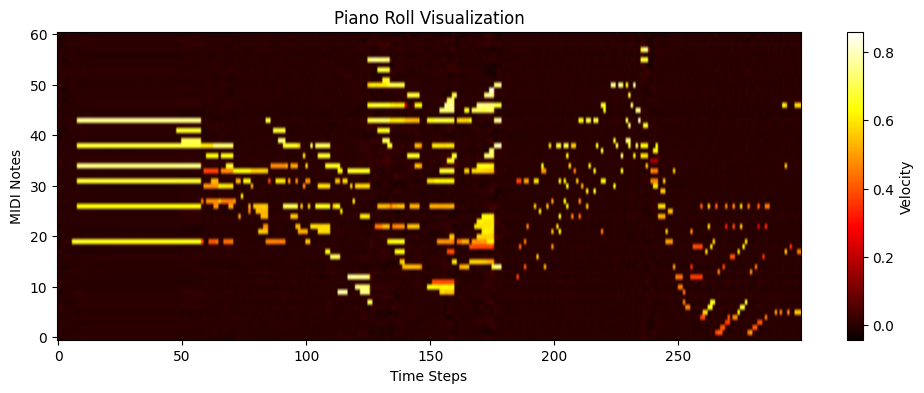

________________________________________________________________________________________________________________________

Processing file: MIDI-UNPROCESSED_04-05_R1_2014_MID--AUDIO_04_R1_2014_wav--4
Original sequence:


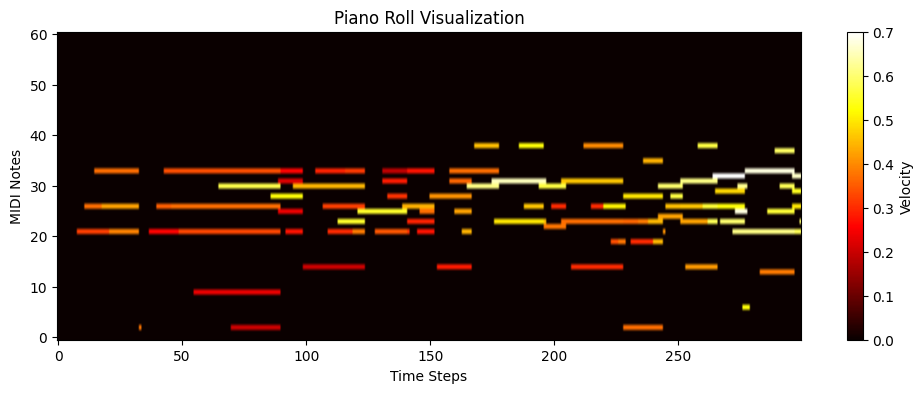

Reconstruction:


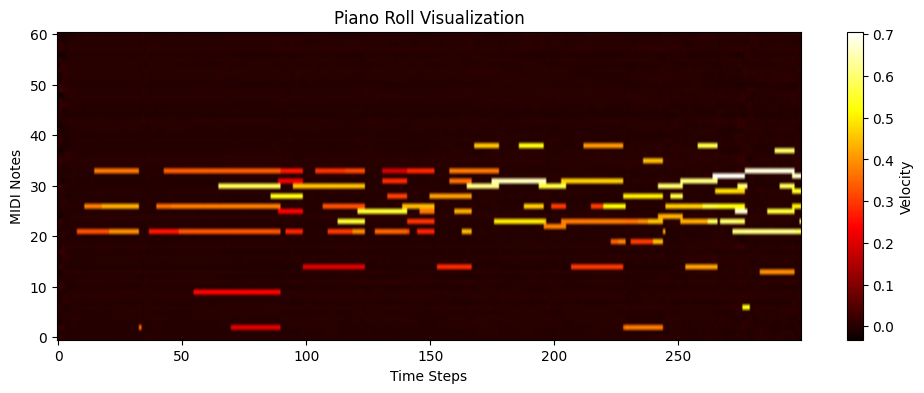

________________________________________________________________________________________________________________________

Processing file: MIDI-UNPROCESSED_04-05_R1_2014_MID--AUDIO_04_R1_2014_wav--5
Original sequence:


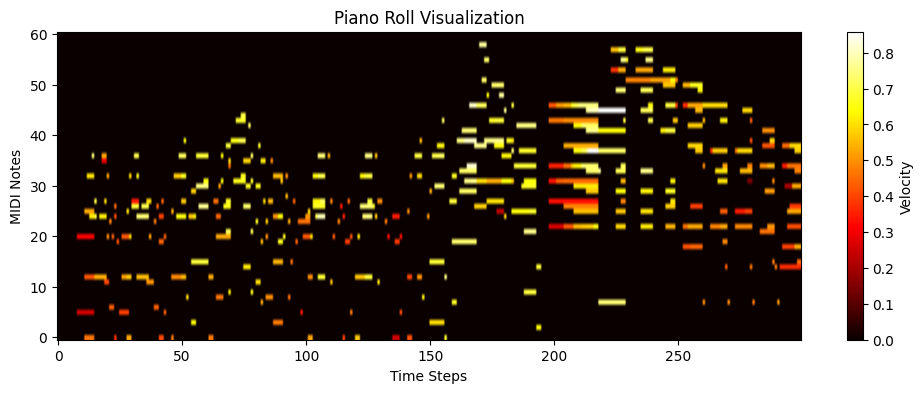

Reconstruction:


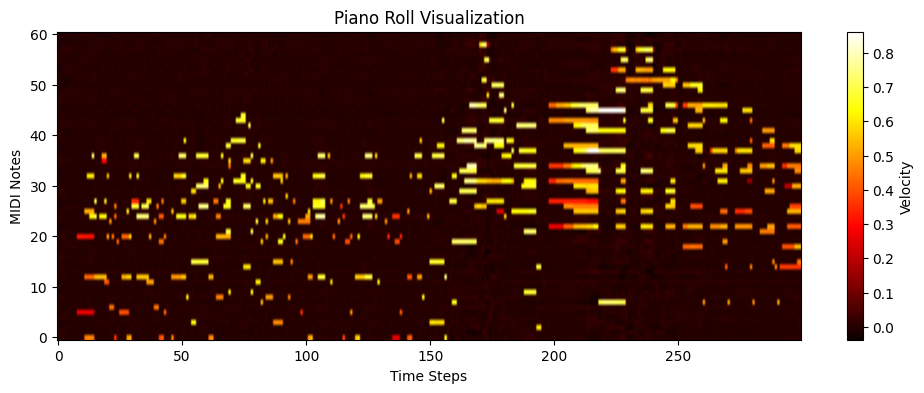

________________________________________________________________________________________________________________________



In [8]:
for i in range(5):
    original_sequence_tensor, original_length_val, filename = dataset[i]
    print(f"Processing file: {filename}")
    print(f"Original sequence:")
    dataset.visualize_midi(original_sequence_tensor)
    print(f"Reconstruction:")
    reconstructions = model.reconstruct(original_sequence_tensor, original_length_val)
    print(60*"__"+"\n")